In [140]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from collections import defaultdict
warnings.filterwarnings("ignore")

In [181]:
ROLE_MAPPINGS = {
    'Role_type.1': 'Power System Analyst',
    'Role_type.2': 'Network Planner',
    'Role_type.3': 'Connection Manager',
    'Role_type.4': 'Operations Planner',
    'Role_type.5': 'Operations Coordinator',
    'Role_type.6': 'Operations Operator',
    'Role_type.7': 'Incident Analyst',
    'Role_type.8': 'Other Role'
}

DECISION_GROUPS = {
    'New Connection and Grid Development Decisions': ['decision_type.1','decision_type.3'],
    'Operation and Coordination Decisions': ['decision_type.2'],
    'Standardisation and Model Decisions': ['decision_type.4','decision_type.5'],
    'Other Decisions': ['decision_type.6','decision_type.7']
}

SIMULATION_MAPPINGS = {
    'simulation_type.1': 'Power Flow Analysis',
    'simulation_type.2': 'State Analysis',
    'simulation_type.3': 'Stochastic Simulations',
    'simulation_type.4': 'Weather Simulation',
    'simulation_type.5': 'Market Simulations',
    'simulation_type.6': 'Time Series Simulations',
    'simulation_type.7': 'Other Simulations',
    'simulation_type.8': 'No Simulations'
}

ANALYSIS_MAPPINGS = {
    'analyze_type.1': 'Outage Analysis',
    'analyze_type.2': 'Operations Analysis',
    'analyze_type.3': 'Load & Generation Modeling',
    'analyze_type.4': 'Economic Analysis',
    'analyze_type.5': 'Other Analysis',
    'analyze_type.6': 'None of These'
}

ANALYSIS_GROUPS = {
    'Outage Analysis': ['analyze_type.1'],
    'Operations Analysis': ['analyze_type.2'],
    'Load & Generation Modeling': ['analyze_type.3'],
    'Economic & Other Analysis': ['analyze_type.4','analyze_type.5','analyze_type.6']
}

SIMULATION_GROUPS = {
    'Load Flow Analysis': ['simulation_type.1'],
    'State & Reliability Analysis': ['simulation_type.2'],
    'Stochastic & Time Series': ['simulation_type.3','simulation_type.6'],
    'Market/Weather & Other': ['simulation_type.4','simulation_type.5','simulation_type.7','simulation_type.8']
}

UNCERTAINTY_GROUP_MAP = {
    'analyze_type1_uncertainty.1': 'Probabilistic Methods',
    'analyze_type1_uncertainty.2': 'Scenario Analysis',
    'analyze_type1_uncertainty.3': 'Fixed value based on Historical Data/Time series',
    'analyze_type1_uncertainty.4': 'Fixed Value based on Expert Judgment',
    'analyze_type3_uncertainty.1': 'Probabilistic Methods',
    'analyze_type3_uncertainty.2': 'Scenario Analysis',
    'analyze_type3_uncertainty.3': 'Time series profile',
    'analyze_type3_uncertainty.4': 'Fixed value based on Historical Data/Time series',
    'analyze_type3_uncertainty.5': 'Fixed Value based on Expert Judgment',
    'simulation_uncertainty.1': 'Probabilistic Methods',
    'simulation_uncertainty.2': 'Scenario Analysis',
    'simulation_uncertainty.3': 'Time series profile',
    'simulation_uncertainty.4': 'Fixed value based on Historical Data/Time series',
    'simulation_uncertainty.5': 'Fixed Value based on Expert Judgment'
}

BARRIERS_MAPPINGS = {
    'software_barrieres.1': 'Results Difficult to Interpret',
    'software_barrieres.2': 'Data Quality Issues',
    'software_barrieres.3': 'Internal Guidelines Not Adapted',
    'software_barrieres.4': 'Time-consuming/Complicated',
    'software_barrieres.5': 'Insufficient Tool Support',
    'software_barrieres.6': 'Insufficient Knowledge',
    'software_barrieres.7': 'Other Barriers',
    'indicators_barriers.1': 'Results Difficult to Interpret',
    'indicators_barriers.2': 'Data Quality Issues',
    'indicators_barriers.3': 'Internal Guidelines Not Adapted',
    'indicators_barriers.4': 'Time-consuming/Complicated',
    'indicators_barriers.5': 'Insufficient Tool Support',
    'indicators_barriers.6': 'Insufficient Knowledge',
    'indicators_barriers.7': 'Other Barriers'
}

SOFTWARE_LIST = [
    'PowerWorld','PSS/E','PowerFactory (DIgSILENT)','MATLAB & Simulink','Python Libraries',
    'NEPLAN','ETAP','OpenDSS','PSCAD/EMTDC','Netbas (Volue/Powel)','Other Commercial Software',
    'Self-developed Software','No Software Used'
]


In [182]:
df = pd.read_csv('data/results.csv', sep=';', encoding='utf-8')
print(f"Loaded {len(df)} responses")


Loaded 24 responses


In [183]:
def label_pct(count,total,label):
    return f"{label}\n({100*count/total:.1f}%)"

def node_counts(df, mapping_group):
    counts = {}
    total = 0
    for col,label in mapping_group.items():
        if col in df:
            cnt = (df[col]==1).sum()
            if cnt>0: 
                counts[label] = cnt
                total += cnt
    return counts,total

def grouped_node_counts(df, groups):
    counts = {}
    total = 0
    for group,cols in groups.items():
        cnt = sum((df[c]==1).sum() for c in cols if c in df)
        if cnt>0:
            counts[group] = cnt
            total += cnt
    return counts,total

def uncertainty_counts(df):
    groups = defaultdict(int)
    for col, name in UNCERTAINTY_GROUP_MAP.items():
        if col in df:
            groups[name] += (df[col]==1).sum()
    total = sum(groups.values())
    return groups,total

def barriers_counts(df):
    groups = defaultdict(int)
    for col,name in BARRIERS_MAPPINGS.items():
        if col in df:
            cnt = (df[col]>=4).sum()
            if cnt>0:
                groups[name] += cnt
    total = sum(groups.values())
    return groups,total

def create_main_sankey_flows(df):
    # Get node counts
    role_counts, role_total = node_counts(df, ROLE_MAPPINGS)
    dec_counts, dec_total = grouped_node_counts(df, DECISION_GROUPS)
    anal_counts, anal_total = grouped_node_counts(df, ANALYSIS_MAPPINGS)
    sim_counts, sim_total = grouped_node_counts(df, SIMULATION_GROUPS)
    unc_counts, unc_total = uncertainty_counts(df)
    bar_counts, bar_total = barriers_counts(df)
    
    # Create clean→display label mapping
    node_to_display = {}
    for k,v in role_counts.items():
        node_to_display[k] = label_pct(v,role_total,k)
    for k,v in dec_counts.items():
        node_to_display[k] = label_pct(v,dec_total,k)
    for k,v in anal_counts.items():
        node_to_display[k] = label_pct(v,anal_total,k)
    for k,v in sim_counts.items():
        node_to_display[k] = label_pct(v,sim_total,k)
    for k,v in unc_counts.items():
        node_to_display[k] = label_pct(v,unc_total,k)
    for k,v in bar_counts.items():
        node_to_display[k] = label_pct(v,bar_total,k)
    
    flows = []
    # Roles -> Decisions
    for rcol,rname in ROLE_MAPPINGS.items():
        if rcol in df and rname in role_counts:
            for dgroup, dcols in DECISION_GROUPS.items():
                if dgroup in dec_counts:
                    cnt = sum(((df[rcol]==1)&(df[dcol]==1)).sum() for dcol in dcols if dcol in df)
                    if cnt>0:
                        flows.append(dict(source=rname, target=dgroup, value=cnt, flow_type='role_decision'))
    # Decisions -> Analysis
    for dgroup, dcols in DECISION_GROUPS.items():
        if dgroup in dec_counts:
            for agroup, acols in ANALYSIS_MAPPINGS.items():
                if agroup in anal_counts:
                    cnt = sum(((df[dcol]==1)&(df[acol]==1)).sum() for dcol in dcols if dcol in df for acol in acols if acol in df)
                    if cnt>0:
                        flows.append(dict(source=dgroup, target=agroup, value=cnt, flow_type='decision_analysis'))
    # Analysis -> Simulations
    for agroup, acols in ANALYSIS_MAPPINGS.items():
        if agroup in anal_counts:
            for sgroup, scols in SIMULATION_GROUPS.items():
                if sgroup in sim_counts:
                    cnt = sum(((df[acol]==1)&(df[scol]==1)).sum() for acol in acols if acol in df for scol in scols if scol in df)
                    if cnt>0:
                        flows.append(dict(source=agroup, target=sgroup, value=cnt, flow_type='analysis_simulation'))
    # Analysis -> Uncertainty (direct)
    for agroup, acols in ANALYSIS_MAPPINGS.items():
        if agroup in anal_counts:
            for ucol,uname in UNCERTAINTY_GROUP_MAP.items():
                if ucol in df and uname in unc_counts:
                    cnt = sum(((df[acol]==1) & (df[ucol]==1)).sum() for acol in acols if acol in df)
                    if cnt>0:
                        flows.append(dict(source=agroup, target=uname, value=cnt, flow_type='analysis_uncertainty'))
    # Simulations -> Uncertainty
    for sgroup, scols in SIMULATION_GROUPS.items():
        if sgroup in sim_counts:
            for ucol,uname in UNCERTAINTY_GROUP_MAP.items():
                if ucol in df and uname in unc_counts:
                    cnt = sum(((df[scol]==1) & (df[ucol]==1)).sum() for scol in scols if scol in df)
                    if cnt>0:
                        flows.append(dict(source=sgroup, target=uname, value=cnt, flow_type='simulation_uncertainty'))
    # Uncertainty -> Barriers
    for uname in unc_counts:
        if uname in unc_counts:
            for bname in bar_counts:
                if bname in bar_counts:
                    flows.append(dict(source=uname, target=bname, value=max(1, bar_counts[bname] // max(1, len(unc_counts))), flow_type='uncertainty_barriers'))
    return flows, node_to_display

def create_main_sankey_flows_linear(df):
    # Count nodes using atomic ANALYSIS_MAPPINGS
    role_counts, role_total = node_counts(df, ROLE_MAPPINGS)
    dec_counts, dec_total = grouped_node_counts(df, DECISION_GROUPS)
    anal_counts, anal_total = node_counts(df, ANALYSIS_MAPPINGS)
    sim_counts, sim_total = grouped_node_counts(df, SIMULATION_GROUPS)
    unc_counts, unc_total = uncertainty_counts(df)
    bar_counts, bar_total = barriers_counts(df)

    node_to_display = {}
    for k,v in role_counts.items():
        node_to_display[k] = label_pct(v, role_total, k)
    for k,v in dec_counts.items():
        node_to_display[k] = label_pct(v, dec_total, k)
    for k,v in anal_counts.items():
        node_to_display[k] = label_pct(v, anal_total, k)
    for k,v in sim_counts.items():
        node_to_display[k] = label_pct(v, sim_total, k)
    for k,v in unc_counts.items():
        node_to_display[k] = label_pct(v, unc_total, k)
    for k,v in bar_counts.items():
        node_to_display[k] = label_pct(v, bar_total, k)

    flows = []
    # Roles -> Decisions
    for rcol, rname in ROLE_MAPPINGS.items():
        if rcol in df and rname in role_counts:
            for dgroup, dcols in DECISION_GROUPS.items():
                if dgroup in dec_counts:
                    cnt = sum(((df[rcol]==1)&(df[dcol]==1)).sum() for dcol in dcols if dcol in df)
                    if cnt>0:
                        flows.append(dict(source=rname, target=dgroup, value=cnt, flow_type='role_decision'))
    # Decisions -> Atomic Analyses
    for dgroup, dcols in DECISION_GROUPS.items():
        if dgroup in dec_counts:
            for acol, aname in ANALYSIS_MAPPINGS.items():
                if acol in df and aname in anal_counts:
                    cnt = sum(((df[dcol]==1)&(df[acol]==1)).sum() for dcol in dcols if dcol in df)
                    if cnt>0:
                        flows.append(dict(source=dgroup, target=aname, value=cnt, flow_type='decision_analysis'))
    # Analysis -> Simulations
    for acol, aname in ANALYSIS_MAPPINGS.items():
        if acol in df and aname in anal_counts:
            for sgroup, scols in SIMULATION_GROUPS.items():
                if sgroup in sim_counts:
                    cnt = sum(((df[acol]==1)&(df[scol]==1)).sum() for scol in scols if scol in df)
                    if cnt>0:
                        flows.append(dict(source=aname, target=sgroup, value=cnt, flow_type='analysis_simulation'))
    # Simulations -> Uncertainty
    for sgroup, scols in SIMULATION_GROUPS.items():
        if sgroup in sim_counts:
            for ucol, uname in UNCERTAINTY_GROUP_MAP.items():
                if ucol in df and uname in unc_counts:
                    cnt = sum(((df[scol]==1) & (df[ucol]==1)).sum() for scol in scols if scol in df)
                    if cnt>0:
                        flows.append(dict(source=sgroup, target=uname, value=cnt, flow_type='simulation_uncertainty'))
    # Uncertainty -> Barriers
    for uname in unc_counts:
        for bname in bar_counts:
            flows.append(dict(
                source=uname, target=bname,
                value=max(1, bar_counts[bname] // max(1, len(unc_counts))),
                flow_type='uncertainty_barriers'
            ))
    return flows, node_to_display


In [184]:
def build_main_sankey(flows, node_to_display):
    # Unique nodes in order of appearance
    all_nodes = []
    for flow in flows:
        if flow['source'] not in all_nodes:
            all_nodes.append(flow['source'])
        if flow['target'] not in all_nodes:
            all_nodes.append(flow['target'])
    display_labels = [node_to_display[node] for node in all_nodes]
    
    # Column assignment
    role_idx = [i for i in all_nodes if i in ROLE_MAPPINGS.values()]
    dec_idx = [i for i in all_nodes if i in DECISION_GROUPS]
    ana_idx = [i for i in all_nodes if i in ANALYSIS_MAPPINGS]
    sim_idx = [i for i in all_nodes if i in SIMULATION_GROUPS]
    unc_idx = [i for i in all_nodes if i in UNCERTAINTY_GROUP_MAP.values()]
    bar_idx = [i for i in all_nodes if i not in role_idx+dec_idx+ana_idx+sim_idx+unc_idx]
    cat_list = [role_idx, dec_idx, ana_idx, sim_idx, unc_idx, bar_idx]
    col_x = [0.02, 0.18, 0.34, 0.48, 0.75, 0.9]
    
    x,y = [0]*len(all_nodes), [0]*len(all_nodes)
    for col, cat in enumerate(cat_list):
        n = len(cat)
        for j, name in enumerate(cat):
            i = all_nodes.index(name)
            x[i] = col_x[col]
            y[i] = 0.15 + j*(0.75/(max(1,n-1)))
    
    color_map = {
        0: 'steelblue', 1: 'crimson', 2:'forestgreen', 3:'blueviolet', 4:'darkorange', 5:'orangered'
    }
    color_arr = []
    for i in range(len(all_nodes)):
        for col,cat in enumerate(cat_list):
            if all_nodes[i] in cat:
                color_arr.append(color_map[col])
    # Link mapping
    node_idx = {name: i for i, name in enumerate(all_nodes)}
    link_colors = {
        'role_decision':'rgba(70,130,180,0.6)','decision_analysis':'rgba(220,20,60,0.6)',
        'analysis_simulation':'rgba(34,139,34,0.6)','analysis_uncertainty':'rgba(220,170,0,0.5)',
        'simulation_uncertainty':'rgba(138,43,226,0.7)','uncertainty_barriers':'rgba(255,69,0,0.7)'
    }
    links = dict(source=[], target=[], value=[], color=[])
    for f in flows:
        links['source'].append(node_idx[f['source']])
        links['target'].append(node_idx[f['target']])
        links['value'].append(f['value'])
        links['color'].append(link_colors.get(f['flow_type'],'rgba(150,150,150,0.5)'))
    fig = go.Figure(go.Sankey(
        arrangement="freeform",
        node=dict(label=display_labels,color=color_arr,x=x,y=y,pad=60,thickness=18),
        link=links))
    # Headers
    for i, h in enumerate(['ROLES','DECISIONS','ANALYSIS','SIMULATIONS','UNCERTAINTY','BARRIERS']):
        fig.add_annotation(x=col_x[i]*1.02, y=1.06, text=f"<b>{h}</b>", showarrow=False, font=dict(size=13))
    fig.update_layout(
        title="Workflow: Roles → Decisions → Analysis/Simulations → Uncertainty → Barriers", 
        height=1200, width=1820,
        margin=dict(l=20, r=20, t=160, b=80))
    return fig


In [185]:
SOFTWARE_MAPPINGS = {
    'PowerWorld':'PowerWorld',
    'PSS/E':'PSS/E',
    'PowerFactory (DIgSILENT)':'PowerFactory (DIgSILENT)',
    'MATLAB & Simulink':'MATLAB & Simulink',
    'Python Libraries':'Python Libraries',
    'Netbas (Volue/Powel)':'Netbas (Volue/Powel)',
    'Other Commercial Software':'Other Commercial Software',
    'Self-developed Software':'Self-developed Software',
    'No Software Used':'No Software Used'
}

def create_detailed_software_flows(df):
    flows = []
    sim_labels = [SIMULATION_MAPPINGS[c] for c in SIMULATION_MAPPINGS if c in df.columns and (df[c]==1).sum()>0]
    for anal_col, anal_label in ANALYSIS_MAPPINGS.items():
        if anal_col in df and (df[anal_col]==1).sum()>0:
            for sim_col, sim_label in SIMULATION_MAPPINGS.items():
                if sim_col in df and (df[sim_col]==1).sum()>0:
                    cnt = ((df[anal_col]==1) & (df[sim_col]==1)).sum()
                    if cnt>0:
                        flows.append({'source':anal_label,'target':sim_label,'value':cnt, 'flow_type':'analysis_simulation'})
    for sim_col, sim_label in SIMULATION_MAPPINGS.items():
        if sim_col in df and (df[sim_col]==1).sum()>0:
            for soft_label in SOFTWARE_MAPPINGS:
                # -- Real logic: if you have columns like 'software.PowerWorld' you can use:
                # cnt = ((df[sim_col]==1)&(df[f'software_{soft_label}']==1)).sum() if f'software_{soft_label}' in df else 0
                cnt = np.random.randint(0,5)  # placeholder, replace with actual cross-tab logic
                if cnt>0:
                    flows.append({'source':sim_label,'target':soft_label,'value':cnt, 'flow_type':'simulation_software'})
    # All percentage display logic is handled in the visualization step
    return flows

def build_detailed_software_sankey(flows):
    # Unique nodes in order
    all_nodes = []
    for flow in flows:
        if flow['source'] not in all_nodes:
            all_nodes.append(flow['source'])
        if flow['target'] not in all_nodes:
            all_nodes.append(flow['target'])
    # Assign columns: analysis(0.15), simulation(0.5), software(0.85)
    analysis_idx = [i for i in all_nodes if i in ANALYSIS_MAPPINGS.values()]
    simulation_idx = [i for i in all_nodes if i in SIMULATION_MAPPINGS.values()]
    software_idx = [i for i in all_nodes if i in SOFTWARE_MAPPINGS.values()]
    idx_groups = [analysis_idx, simulation_idx, software_idx]
    col_x = [0.15, 0.50, 0.85]
    x,y = [0]*len(all_nodes), [0]*len(all_nodes)
    for i,group in enumerate(idx_groups):
        n = len(group)
        for j, name in enumerate(group):
            k = all_nodes.index(name)
            x[k]=col_x[i]
            y[k]=0.1+j*0.8/(max(1,n-1)) if n>1 else 0.5
    color_arr = []
    for i in range(len(all_nodes)):
        if i in [all_nodes.index(name) for name in analysis_idx]:
            color_arr.append('forestgreen')
        elif i in [all_nodes.index(name) for name in simulation_idx]:
            color_arr.append('blueviolet')
        else:
            color_arr.append('deepskyblue')
    # Link colors
    link_colors = {'analysis_simulation':'rgba(34,139,34,0.6)','simulation_software':'rgba(0,191,255,0.6)'}
    node_idx = {name: i for i, name in enumerate(all_nodes)}
    links = dict(source=[], target=[], value=[], color=[])
    for f in flows:
        links['source'].append(node_idx[f['source']])
        links['target'].append(node_idx[f['target']])
        links['value'].append(f['value'])
        links['color'].append(link_colors.get(f['flow_type'],'rgba(150,150,150,0.5)'))
    fig = go.Figure(go.Sankey(
        arrangement="freeform",
        node=dict(label=all_nodes,color=color_arr,
                  x=x,y=y,pad=15,thickness=12),
        link=links))
    for i,h in enumerate(['ANALYSIS','SIMULATIONS','SOFTWARE']):
        fig.add_annotation(x=col_x[i], y=1.03, text=f"<b>{h}</b>", showarrow=False, font=dict(size=13))
    fig.update_layout(title="Detailed Analysis → Simulation → Software Tools",
                     height=950, width=1400)
    return fig


In [186]:
def create_software_pie_chart(df):
    # This assumes you have a binary (0/1) variable for each tool
    # For demo, we'll simulate; replace as needed
    tools = SOFTWARE_LIST
    cnts = [np.random.randint(1,12) for _ in tools] # Replace with counts from your df
    total = sum(cnts)
    fig,ax = plt.subplots(figsize=(7,7))
    ax.pie(cnts, labels=tools, autopct='%1.1f%%', startangle=140, pctdistance=0.85)
    ax.set_title('Software Tool Usage')
    centre_circle = plt.Circle((0,0),0.70,fc='white')
    fig.gca().add_artist(centre_circle)
    plt.tight_layout()
    plt.show()


In [187]:
def create_uncertainty_barriers_bars(df):
    # Usage by uncertainty method
    unc_usage = defaultdict(int)
    for col, group in UNCERTAINTY_GROUP_MAP.items():
        if col in df:
            unc_usage[group] += (df[col]==1).sum()
    methods = list(unc_usage.keys())
    total_unc = sum(unc_usage.values())
    pct = [val/total_unc*100 for val in unc_usage.values()]
    plt.bar(methods, pct, color='orange')
    plt.ylabel("Usage (%)")
    plt.title("Uncertainty Modeling Usage")
    plt.show()

    # Barrier severity
    bar_sev = defaultdict(list)
    for col, name in BARRIERS_MAPPINGS.items():
        if col in df:
            bar_sev[name].append(df[col].mean())
    bars, avgs = list(bar_sev.keys()), [np.mean(bar_sev[k]) for k in bar_sev]
    plt.bar(bars, avgs, color='crimson')
    plt.ylabel("Mean Severity")
    plt.title("Average Barrier Severity (1=No, 5=Critical)")
    plt.xticks(rotation=45, ha='right')
    plt.show()

import matplotlib.pyplot as plt
import numpy as np

def plot_uncertainty_bars(df, method="bar"):
    # Build count of unique respondents per uncertainty method
    method_names = list(set(UNCERTAINTY_GROUP_MAP.values()))
    method_counts = {m: 0 for m in method_names}
    total = len(df)
    for m in method_names:
        # find all columns mapped to this method
        cols = [col for col, name in UNCERTAINTY_GROUP_MAP.items() if name == m]
        selection = df[cols].any(axis=1)
        method_counts[m] = selection.sum()
    # Sort for presentation
    method_names_sorted = sorted(method_counts.keys(), key=lambda x: -method_counts[x])
    counts = [method_counts[m] for m in method_names_sorted]
    percentages = [100*c/total for c in counts]

    fig, ax = plt.subplots(figsize=(8,5))
    bars = ax.bar(method_names_sorted, percentages, color='orange', alpha=0.7)
    # Add value labels
    for bar, pct, n in zip(bars, percentages, percentages):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8, f"{n}", ha='center', va='bottom', fontsize=11, fontweight="bold")
    # Tilt x-labels for room
    plt.xticks(rotation=20, ha='right')
    ax.set_ylabel("Respondents Using Method (%)")
    ax.set_ylim(0, max(percentages) * 1.18)
    ax.set_title("Prevalence of Uncertainty Modelling Methods")
    plt.tight_layout()
    plt.show()

def plot_uncertainty_stacked(df, stack_on='simulation'):  # or stack_on='analysis'
    # Prepare the stack categories
    if stack_on=='simulation':
        stacks = list(SIMULATION_GROUPS.keys())
        stack_map = {}
        for key, group in SIMULATION_GROUPS.items():
            for col in group:
                stack_map[col] = key
    else:
        stacks = list(ANALYSIS_MAPPINGS.keys())
        stack_map = {}
        for key, group in ANALYSIS_MAPPINGS.items():
            for col in group:
                stack_map[col] = key

    method_names = sorted(set(UNCERTAINTY_GROUP_MAP.values()))
    total = len(df)

    # Build a count matrix: rows=uncertainty method, cols=stack (sim or analysis group)
    matrix = np.zeros((len(method_names), len(stacks)))
    for i, m in enumerate(method_names):
        u_cols = [col for col, u_m in UNCERTAINTY_GROUP_MAP.items() if u_m == m]
        u_mask = df[u_cols].any(axis=1)
        for j, s in enumerate(stacks):
            s_cols = [col for col, g in stack_map.items() if g == s]
            s_mask = df[s_cols].any(axis=1)
            matrix[i, j] = ((u_mask) & (s_mask)).sum()

    # Now plot it, stacking across the selected grouping
    fig, ax = plt.subplots(figsize=(10,6))
    bottoms = np.zeros(len(method_names))
    for j, s in enumerate(stacks):
        vals = matrix[:, j]
        bars = ax.bar(method_names, vals, bottom=bottoms, label=s)
        bottoms += vals
    # Add value labels to the top segment only
    for idx, (x, y) in enumerate(zip(method_names, bottoms)):
        if y>0:
            ax.text(idx, y+0.3, f"{int(y)}", ha='center', va='bottom', fontsize=10, fontweight="bold")
    plt.xticks(rotation=20, ha='right')
    ax.set_ylabel("Number of Respondents")
    ax.set_title(f"Uncertainty Methods by {'Simulation Type' if stack_on=='simulation' else 'Analysis Method'}")
    plt.legend(title=("Simulation Type" if stack_on=='simulation' else "Analysis Method"), bbox_to_anchor=(1.04,1), loc="upper left")
    plt.tight_layout()
    plt.show()



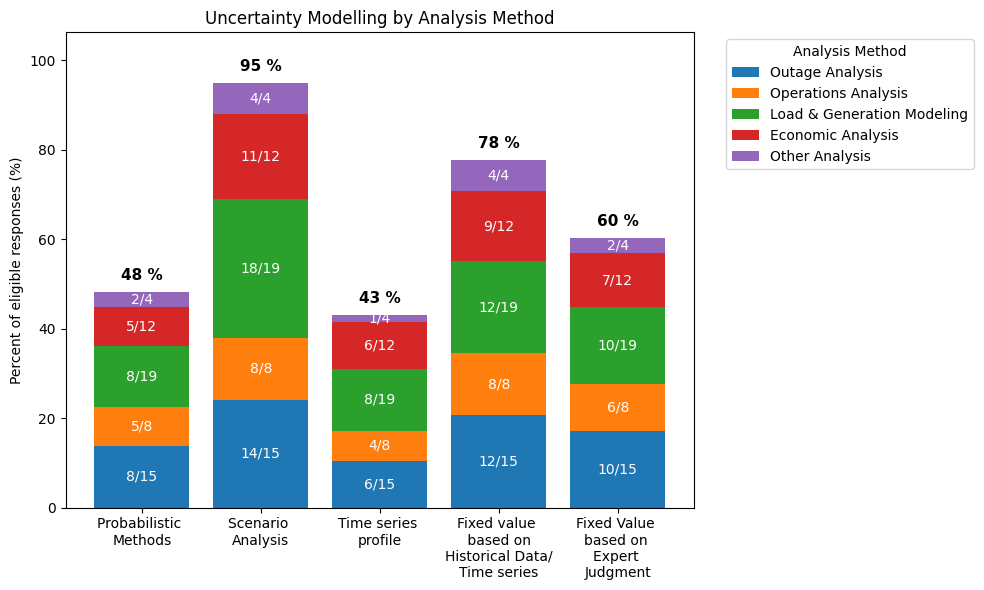

In [ ]:
def plot_uncertainty_stacked_per_eligibility(df):
    # Define in the order you prefer:
    analyses = [k for k, v in ANALYSIS_MAPPINGS.items() if v !="None of These"] # where k is the column name, v is the display name
    unc_methods = ["Probabilistic Methods","Scenario Analysis","Time series profile","Fixed value based on Historical Data/Time series","Fixed Value based on Expert Judgment"]
    unc_methods_labels = ["Probabilistic \nMethods","Scenario \nAnalysis","Time series \nprofile","Fixed value \n based on \nHistorical Data/\nTime series","Fixed Value \nbased on \nExpert \nJudgment"]
    
    numer = np.zeros((len(unc_methods), len(analyses)), dtype=int) #matrix with uncertainty methods as rows, analyses as columns for the numerator
    denom = np.zeros((len(unc_methods), len(analyses)), dtype=int) #matrix with uncertainty methods as rows, analyses as columns for the denominator
    for j, acol in enumerate(analyses):
        # Eligible: respondents who answer any in analysis-group
        

        eligible = df[acol] ==1 if acol in df else np.zeros(lned(df),dtype=bool) # check if analysis column exists and create a boolean mask to filter eligible respondents (only elegible respondents will be counted)

        for i, u_method in enumerate(unc_methods):
            # All uncertainty cols for this method and this analysis type
            unc_cols = [
                col for col, val in UNCERTAINTY_GROUP_MAP.items() # find all uncertainty columns that match the current method
                if val == u_method and any(pcol.split('.')[0] in col for pcol in acol) # check if the uncertainty column is related to the current analysis type
            ]
            if not unc_cols: # if no uncertainty columns found for this method and analysis, skip
                continue
            # n/N: sum YES for this unc across analyses / sum eligible for that analysis
            numer[i,j] = (df[unc_cols].any(axis=1) & eligible).sum() # count how many respondents answered YES to any of the uncertainty columns for this method and analysis
            denom[i,j] = eligible.sum() # count how many respondents are eligible for this analysis type

    # Now, collapse across all analyses for "overall" bar: sum across columns (per method = ALL eligible for any analysis)
    numer_sum = numer.sum(axis=1)
    denom_sum = denom.sum(axis=1)
    total_pct = np.divide(numer_sum, denom_sum, out=np.zeros_like(numer_sum, dtype=float), where=denom_sum>0) * 100

    # --- Stacked Bar: each analysis as stack for every unc-method
    fig, ax = plt.subplots(figsize=(10,6))
    bottoms = np.zeros(len(unc_methods))
    for j, analysis in enumerate(analyses):
        aname= ANALYSIS_MAPPINGS[analysis]
        
        pct = np.divide(numer[:,j], denom_sum, out=np.zeros_like(numer[:,j], dtype=float), where=denom[:,j]>0) * 100
        bars = ax.bar(unc_methods_labels, pct, bottom=bottoms, label=aname)
        # label each segment with n/N
        for i in range(len(unc_methods)):
            if pct[i]>0.1:
                ax.text(i, bottoms[i]+pct[i]/2, f"{numer[i,j]}/{denom[i,j]}", ha="center", va="center", fontsize=10, color='white')#, fontweight="bold")
        bottoms += pct
    # Also add the overall bar value at the top
    for i, height in enumerate(bottoms):
        if denom_sum[i]>0:
            ax.text(i, height+2, f"{(numer_sum[i]/denom_sum[i])*100:.0f} %", ha="center", va="bottom", fontsize=11, fontweight="bold", color='k')

    ax.set_ylim(0, min(110, 1.12*bottoms.max()))
    #plt.xticks(rotation=00, ha='center')
    plt.ylabel("Percent of eligible responses (%)")
    plt.title("Uncertainty Modelling by Analysis Method")
    plt.legend(title="Analysis Method", bbox_to_anchor=(1.04,1), loc="upper left")
    plt.tight_layout()
    plt.show()
plot_uncertainty_stacked_per_eligibility(df)

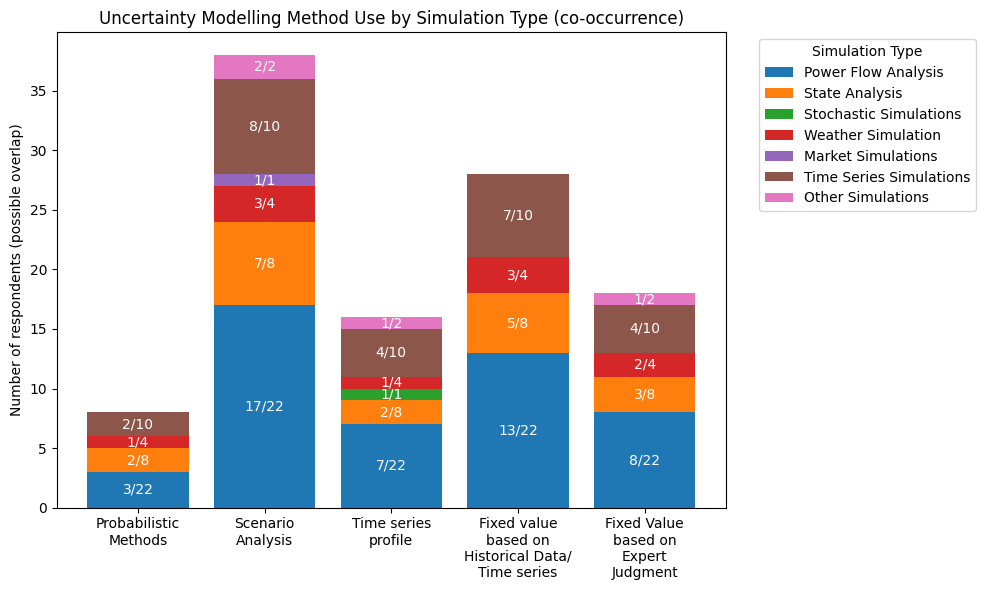

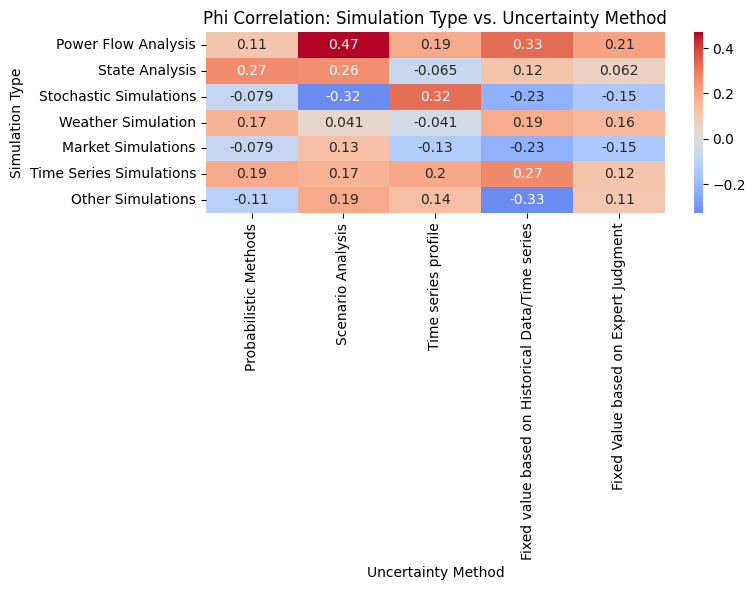

In [213]:
def plot_simulation_uncertainty_stacked_counts(df):
    sims = [k for k, v in SIMULATION_MAPPINGS.items() if v != "No Simulations"]
    unc_methods = [
        "Probabilistic Methods",
        "Scenario Analysis",
        "Time series profile",
        "Fixed value based on Historical Data/Time series",
        "Fixed Value based on Expert Judgment"
    ]
    unc_labels = [
        "Probabilistic\nMethods",
        "Scenario\nAnalysis",
        "Time series\nprofile",
        "Fixed value\nbased on\nHistorical Data/\nTime series",
        "Fixed Value\nbased on\nExpert\nJudgment"
    ]

    counts = np.zeros((len(unc_methods), len(sims)), dtype=int)
    eligible = np.zeros(len(sims), dtype=int)
    for j, scol in enumerate(sims):
        eligible_mask = df[scol] == 1 if scol in df else np.zeros(len(df), dtype=bool)
        eligible[j] = eligible_mask.sum()
        for i, u_method in enumerate(unc_methods):
            # Find all simulation uncertainty columns mapped to this method
            unc_cols = [
                col for col, val in UNCERTAINTY_GROUP_MAP.items()
                if val == u_method and "simulation" in col  # Only simulation-based uncertainty columns
            ]
            if not unc_cols: continue
            counts[i, j] = (df[unc_cols].any(axis=1) & eligible_mask).sum()

    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(10,6))
    bottoms = np.zeros(len(unc_methods))
    colors = plt.get_cmap("Set2")(np.linspace(0, 1, len(sims)))
    for j, scol in enumerate(sims):
        sname = SIMULATION_MAPPINGS[scol]
        bar_counts = counts[:, j]
        bars = ax.bar(unc_labels, bar_counts, bottom=bottoms, label=sname)#, color=colors[j])
        for i in range(len(unc_methods)):
            if bar_counts[i] > 0:
                ax.text(i, bottoms[i] + bar_counts[i] / 2, f"{bar_counts[i]}/{eligible[j]}",
                        ha="center", va="center", fontsize=10, color="white")
        bottoms += bar_counts
    ax.set_ylabel("Number of respondents (possible overlap)")
    plt.title("Uncertainty Modelling Method Use by Simulation Type (co-occurrence)")
    plt.legend(title="Simulation Type", bbox_to_anchor=(1.04,1), loc="upper left")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
def simulation_uncertainty_correlation_heatmap(df):
    import seaborn as sns

    sims = [k for k, v in SIMULATION_MAPPINGS.items() if v != "No Simulations"]
    unc_methods = [
        "Probabilistic Methods",
        "Scenario Analysis",
        "Time series profile",
        "Fixed value based on Historical Data/Time series",
        "Fixed Value based on Expert Judgment"
    ]

    matrix = np.zeros((len(sims), len(unc_methods)))
    for i, scol in enumerate(sims):
        sim_yes = df[scol] == 1 if scol in df else np.zeros(len(df), dtype=bool)
        for j, u_method in enumerate(unc_methods):
            unc_cols = [
                col for col, val in UNCERTAINTY_GROUP_MAP.items()
                if val == u_method and "simulation" in col
            ]
            if not unc_cols or not sim_yes.any(): continue
            method_yes = df[unc_cols].any(axis=1)
            # Phi coefficient (correlation between binary variables)
            a = sim_yes & method_yes
            b = sim_yes & ~method_yes
            c = ~sim_yes & method_yes
            d = ~sim_yes & ~method_yes
            n = len(df)
            ad = (a.sum()*d.sum())
            bc = (b.sum()*c.sum())
            den = np.sqrt((a.sum()+b.sum()) * (c.sum()+d.sum()) * (a.sum()+c.sum()) * (b.sum()+d.sum()))
            phi = ((a.sum()*d.sum() - b.sum()*c.sum()) / den) if den > 0 else np.nan
            matrix[i, j] = phi

    fig, ax = plt.subplots(figsize=(8,6))
    sns.heatmap(matrix, annot=True, xticklabels=unc_methods, yticklabels=[SIMULATION_MAPPINGS[k] for k in sims],
                cmap="coolwarm", center=0, ax=ax)
    plt.title("Phi Correlation: Simulation Type vs. Uncertainty Method")
    plt.xlabel("Uncertainty Method")
    plt.ylabel("Simulation Type")
    plt.tight_layout()
    plt.show()

plot_simulation_uncertainty_stacked_counts(df)
simulation_uncertainty_correlation_heatmap(df)

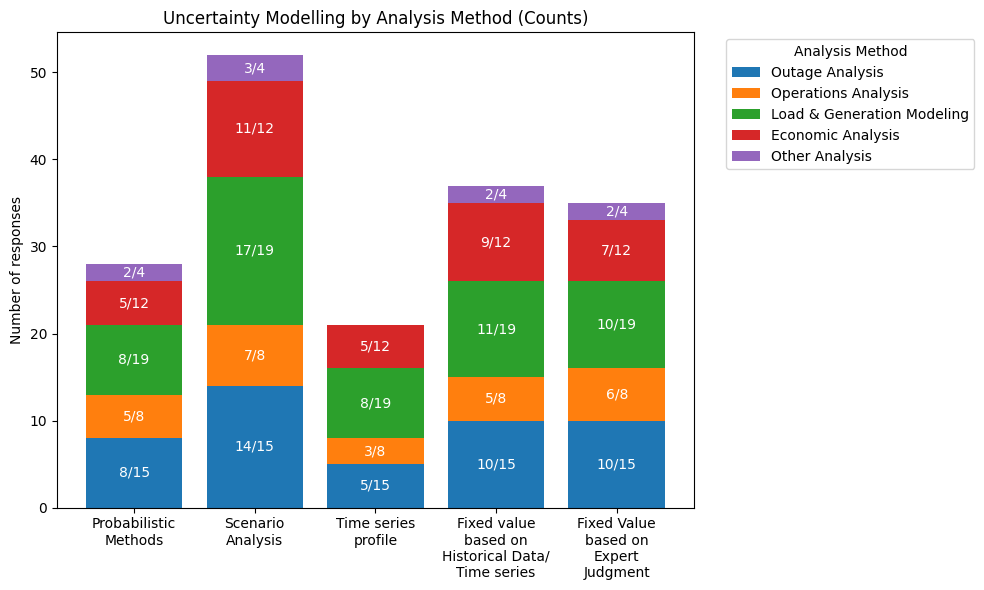

In [209]:
def plot_uncertainty_stacked_counts(df):
    # Only use meaningful atomic analysis (exclude 'None of These')
    analyses = [k for k, v in ANALYSIS_MAPPINGS.items() if v != "None of These"]
    unc_methods = [
        "Probabilistic Methods",
        "Scenario Analysis",
        "Time series profile",
        "Fixed value based on Historical Data/Time series",
        "Fixed Value based on Expert Judgment"
    ]
    unc_methods_labels = [
        "Probabilistic\nMethods",
        "Scenario\nAnalysis",
        "Time series\nprofile",
        "Fixed value\nbased on\nHistorical Data/\nTime series",
        "Fixed Value\nbased on\nExpert\nJudgment"
    ]

    numer = np.zeros((len(unc_methods), len(analyses)), dtype=int)
    denom = np.zeros((len(unc_methods), len(analyses)), dtype=int)
    for j, acol in enumerate(analyses):
        eligible = df[acol] == 1 if acol in df else np.zeros(len(df), dtype=bool)
        for i, u_method in enumerate(unc_methods):
            unc_cols = [
                col for col, val in UNCERTAINTY_GROUP_MAP.items()
                if val == u_method and acol.split('.')[0] in col
            ]
            if not unc_cols:
                continue
            numer[i, j] = (df[unc_cols].any(axis=1) & eligible).sum()
            denom[i, j] = eligible.sum()

    # Make the stacked barplot with counts only
    fig, ax = plt.subplots(figsize=(10, 6))
    bottoms = np.zeros(len(unc_methods))
    colors = plt.get_cmap("Set2")(np.linspace(0, 1, len(analyses)))
    for j, acol in enumerate(analyses):
        aname = ANALYSIS_MAPPINGS[acol]
        counts = numer[:, j]
        bars = ax.bar(unc_methods_labels, counts, bottom=bottoms, label=aname)#, color=colors[j])
        # label each segment with n/N (count/eligible)
        for i in range(len(unc_methods)):
            if counts[i] > 0:
                ax.text(i, bottoms[i] + counts[i] / 2, f"{counts[i]}/{denom[i, j]}",
                        ha="center", va="center", fontsize=10, color="white")
        bottoms += counts
    # y-axis, legend, and labels
    plt.xticks(rotation=0, ha='center')
    ax.set_ylabel("Number of responses")
    plt.title("Uncertainty Modelling by Analysis Method (Counts)")
    plt.legend(title="Analysis Method", bbox_to_anchor=(1.04, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
plot_uncertainty_stacked_counts(df)

In [ ]:
### new method
import matplotlib.pyplot as plt
import numpy as np


def plot_uncertainty_stacked_atomic(df):
    unc_methods = ["Probabilistic Methods","Scenario Analysis","Historical Data","Expert Judgment"]
    analyses = list(ANALYSIS_MAPPINGS.values())
    numer = np.zeros((len(unc_methods), len(analyses)), dtype=int)
    denom = np.zeros((len(unc_methods), len(analyses)), dtype=int)
    denom_total = 0

    for j, (acol, aname) in enumerate(ANALYSIS_MAPPINGS.items()):
        eligible = (df[acol] == 1) if acol in df else np.zeros(len(df), dtype=bool) # eligible for this analysis if they answered YES
        denom_total += eligible.sum()
        for i, u_method in enumerate(unc_methods):
            unc_cols = [
                col for col, val in UNCERTAINTY_GROUP_MAP.items()
                if val == u_method and acol.split('.')[0] in col # atomic analysis match   
            ]
            if not unc_cols: continue
            selected = df[unc_cols].any(axis=1) & eligible
            numer[i, j] = selected.sum()

    total_numer = numer.sum(axis=1)
    pct = numer / denom_total * 100
    fig, ax = plt.subplots(figsize=(10,6))
    bottoms = np.zeros(len(unc_methods))
    colors = plt.get_cmap("Set2")(np.linspace(0,1,len(analyses)))
    for j, aname in enumerate(analyses):
        bars = ax.bar(unc_methods, pct[:,j], bottom=bottoms, label=aname, color=colors[j])
        for i in range(len(unc_methods)):
            if numer[i,j]>0:
                ax.text(i, bottoms[i]+pct[i,j]/2, f"{numer[i,j]}/{denom[i,j]}", ha="center", va="center", fontsize=10)
        bottoms += pct[:,j]
    for i in range(len(unc_methods)):
        if bottoms[i]>0:
            ax.text(i, bottoms[i]+2, f"Total {total_numer[i]}/{denom_total}", ha="center", va="bottom", fontsize=11, fontweight="bold")
    plt.xticks(rotation=18, ha='right')
    plt.ylim(0, min(110, 1.12*bottoms.max()))
    ax.set_ylabel("Percent of all eligible uncertainty answers (%)")
    ax.set_title("Uncertainty Methods by (Atomic) Analysis (normalized by all eligible opportunities)")
    plt.legend(title="Analysis Type", bbox_to_anchor=(1.04,1), loc="upper left")
    plt.tight_layout()
    plt.show()
    print(f"Each segment = YES for (method, analysis) / all YES opportunities (all respondents × all analyses); bar heights never exceed 100%.")


def plot_uncertainty_stacked_totalcorrect(df):
    unc_methods = ["Probabilistic Methods", "Scenario Analysis", "Historical Data", "Expert Judgment"]
    analyses = list(ANALYSIS_MAPPINGS.values())
    n_methods = len(unc_methods)
    n_analyses = len(analyses)
    numer = np.zeros((n_methods, n_analyses), dtype=int)
    denom_total = 0

    for j, (acol, aname) in enumerate(ANALYSIS_MAPPINGS.items()):
        eligible = (df[acol] == 1) if acol in df else np.zeros(len(df), dtype=bool)
        denom_total += eligible.sum()
        for i, u_method in enumerate(unc_methods):
            unc_cols = [
                col for col, val in UNCERTAINTY_GROUP_MAP.items()
                if val == u_method and acol.split('.')[0] in col
            ]
            if not unc_cols: continue
            selected = df[unc_cols].any(axis=1) & eligible
            numer[i, j] = selected.sum()

    total_numer = numer.sum(axis=1)
    pct = numer / denom_total * 100

    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(10,6))
    bottoms = np.zeros(len(unc_methods))
    colors = plt.get_cmap("Set2")(np.linspace(0,1,len(analyses)))
    for j, aname in enumerate(analyses):
        bars = ax.bar(unc_methods, pct[:,j], bottom=bottoms, label=aname, color=colors[j])
        for i in range(len(unc_methods)):
            if numer[i,j]>0:
                ax.text(i, bottoms[i]+pct[i,j]/2, f"{numer[i,j]}/{denom_total}", ha="center", va="center", fontsize=10)
        bottoms += pct[:,j]
    for i in range(len(unc_methods)):
        if bottoms[i]>0:
            ax.text(i, bottoms[i]+2, f"Total {total_numer[i]}/{denom_total}", ha="center", va="bottom", fontsize=11, fontweight="bold")
    plt.xticks(rotation=18, ha='right')
    plt.ylim(0, min(110, 1.12*bottoms.max()))
    ax.set_ylabel("Percent of all eligible responses (%)")
    ax.set_title("Uncertainty Methods by Analysis (atomic; normalized by all eligible)")
    plt.legend(title="Analysis Type", bbox_to_anchor=(1.04,1), loc="upper left")
    plt.tight_layout()
    plt.show()



In [153]:
# Main Sankey
flows, labels = create_main_sankey_flows_linear(df)
fig1 = build_main_sankey(flows, labels)
fig1.show()


In [91]:
# Detailed software Sankey
flows_detail = create_detailed_software_flows(df)
fig2 = build_detailed_software_sankey(flows_detail)
fig2.show()

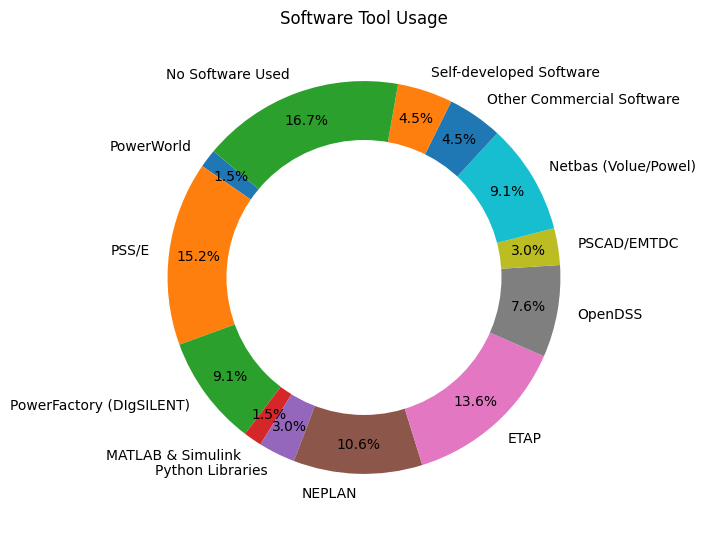

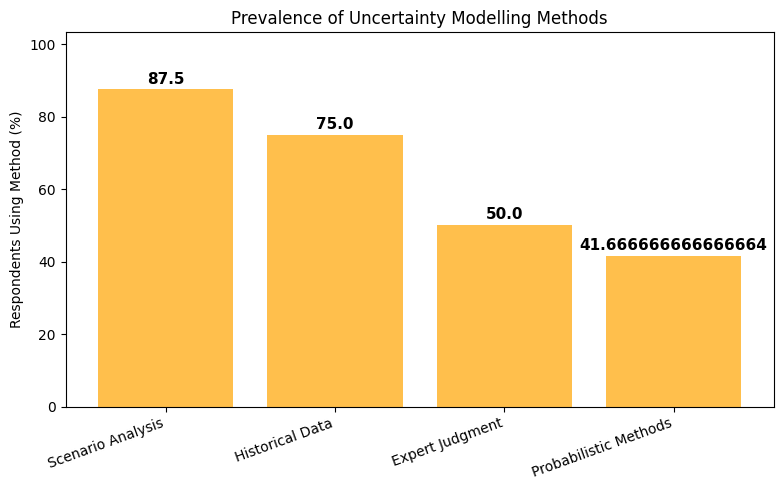

KeyError: 'Outage Analysis'

In [165]:


# Pie chart of software distribution
create_software_pie_chart(df)
plot_uncertainty_bars(df)
plot_uncertainty_stacked_per_eligibility(df)
#plot_uncertainty_stacked_atomic(df)
plot_uncertainty_stacked_totalcorrect(df)
# Uncertainty/barrier barplots
create_uncertainty_barriers_bars(df)

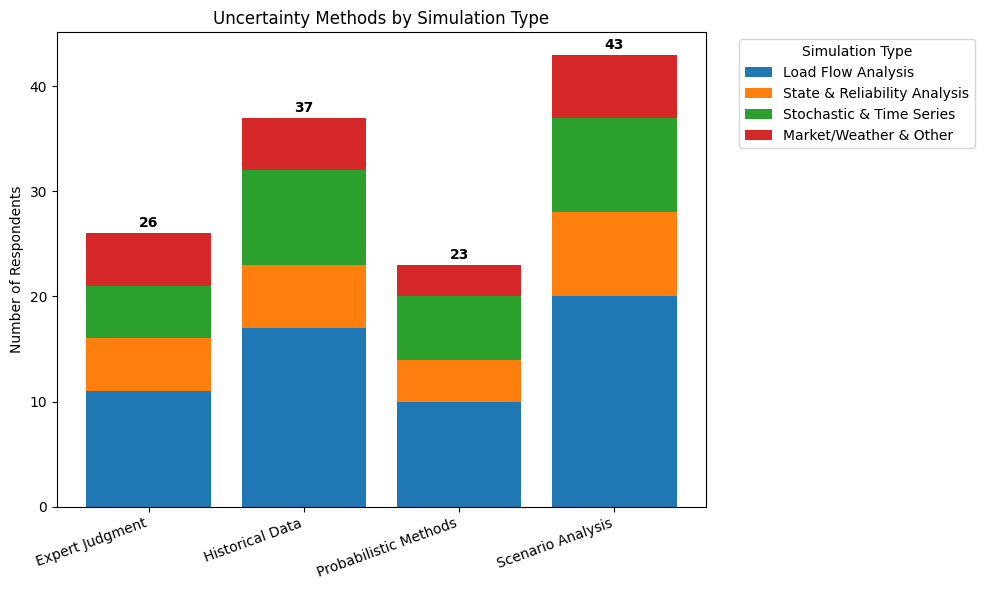

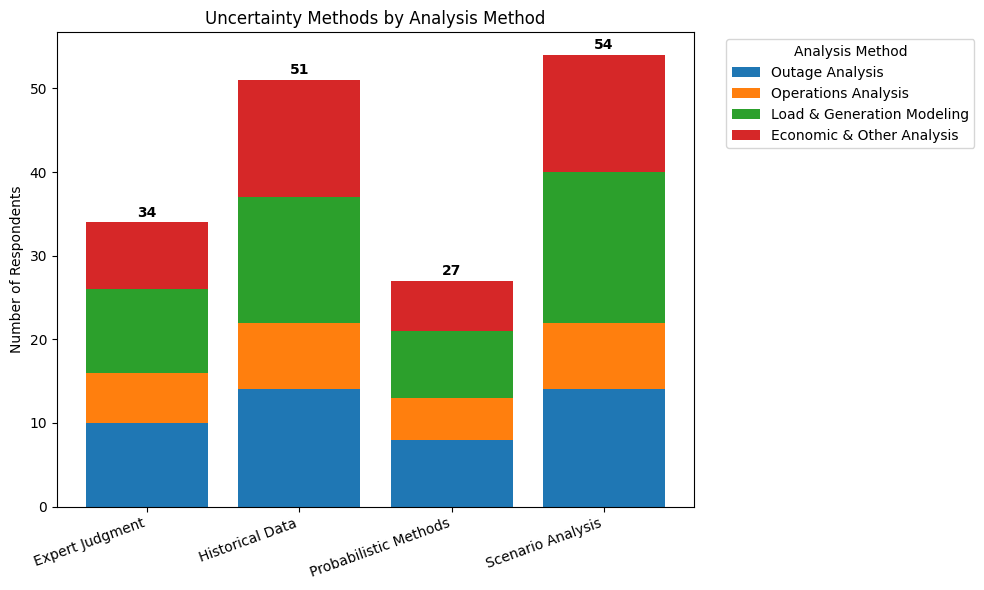

In [100]:
plot_uncertainty_stacked(df, stack_on='simulation')   # stack by simulation type
plot_uncertainty_stacked(df, stack_on='analysis')     # stack by analysis method


In [161]:
def get_main_choice(df, columns, labels):
    result = []
    for _, row in df.iterrows():
        main = "None"
        for col in columns:
            if col in df.columns and row[col] == 1:
                main = labels.get(col, col)
                break
        result.append(main)
    return result

def parallel_categories_mainpaths(df):
    dec_map = {c: g for g, cs in DECISION_GROUPS.items() for c in cs}
    anal_map = ANALYSIS_MAPPINGS # now atomic
    sim_map = {c: g for g, cs in SIMULATION_GROUPS.items() for c in cs}
    pdata = pd.DataFrame({
        'role': get_main_choice(df, list(ROLE_MAPPINGS.keys()), ROLE_MAPPINGS),
        'decision': get_main_choice(df, [c for cs in DECISION_GROUPS.values() for c in cs], dec_map),
        'analysis': get_main_choice(df, list(ANALYSIS_MAPPINGS.keys()), anal_map),
        'simulation': get_main_choice(df, [c for cs in SIMULATION_GROUPS.values() for c in cs], sim_map),
        'uncertainty': get_main_choice(df, list(UNCERTAINTY_GROUP_MAP.keys()), UNCERTAINTY_GROUP_MAP),
        'barrier': get_main_choice(df, list(BARRIERS_MAPPINGS.keys()), BARRIERS_MAPPINGS)
    })
    import plotly.express as px
    fig = px.parallel_categories(
        pdata, 
        dimensions=["role", "decision", "analysis", "simulation", "uncertainty", "barrier"],
        color="role"
    )
    fig.update_layout(title="Parallel Categories: Main Path Choices (Atomic Analysis)")
    fig.show()
parallel_categories_mainpaths(df)


ValueError: 
    Invalid element(s) received for the 'color' property of parcats.line
        Invalid elements include: ['Operations Planner', 'Connection Manager', 'Power System Analyst', 'Power System Analyst', 'Operations Operator', 'Other Role', 'Power System Analyst', 'Power System Analyst', 'Power System Analyst', 'Power System Analyst']

    The 'color' property is a color and may be specified as:
      - A hex string (e.g. '#ff0000')
      - An rgb/rgba string (e.g. 'rgb(255,0,0)')
      - An hsl/hsla string (e.g. 'hsl(0,100%,50%)')
      - An hsv/hsva string (e.g. 'hsv(0,100%,100%)')
      - A named CSS color: see https://plotly.com/python/css-colors/ for a list
      - A number that will be interpreted as a color
        according to parcats.line.colorscale
      - A list or array of any of the above

In [ ]:
def build_full_parcoords_df(df):
    rows = []
    for idx, row in df.iterrows():
        for rcol, rlab in ROLE_MAPPINGS.items():
            if rcol in df and row[rcol]==1:
                for dec_g, dec_cols in DECISION_GROUPS.items():
                    for dcol in dec_cols:
                        if dcol in df and row[dcol]==1:
                            for anal_g, anal_cols in ANALYSIS_MAPPINGS.items():
                                for acol in anal_cols:
                                    if acol in df and row[acol]==1:
                                        for sim_g, sim_cols in SIMULATION_GROUPS.items():
                                            for scol in sim_cols:
                                                if scol in df and row[scol]==1:
                                                    for ucol, ulag in UNCERTAINTY_GROUP_MAP.items():
                                                        if ucol in df and row[ucol]==1:
                                                            for bcol, blag in BARRIERS_MAPPINGS.items():
                                                                if bcol in df and row[bcol]>=4:
                                                                    rows.append({
                                                                        "role": rlab,
                                                                        "decision": dec_g,
                                                                        "analysis": anal_g,
                                                                        "simulation": sim_g,
                                                                        "uncertainty": ulag,
                                                                        "barrier": blag
                                                                    })
    return pd.DataFrame(rows)

pcat_df = build_full_parcoords_df(df)
if len(pcat_df)>0:
    fig = px.parallel_categories(
        pcat_df.sample(3000) if len(pcat_df)>3000 else pcat_df,
        dimensions=["role","decision","analysis","simulation","uncertainty","barrier"],
        labels={k: k.title() for k in pcat_df.columns}
    )
    fig.update_layout(title="Parallel Categories: All Selected Paths (subset for readability)")
    fig.show()
    print(len(pcat_df), "valid cross-selections found in data.")
else:
    print("No valid cross-selections found in data.")


14407 valid cross-selections found in data.


In [ ]:
from collections import defaultdict
import pandas as pd
import plotly.express as px

# Build a dataframe for parallel categories (one row per respondent)
def build_parallel_categories_df(df):
    # For each respondent, map the highest-ranking (or any "Yes"/selected) in each group
    records = []
    for idx, row in df.iterrows():
        # pick first True in each group (if multiple are checked, you may want to adapt this!)
        def pick(mapping):
            for col, label in mapping.items():
                if col in df.columns and row[col]==1:
                    return label
            return "None"
        def pick_group(group):
            for col in group:
                if col in df.columns and row[col]==1:
                    return col  # returns colname
            return "None"
        # Roles
        role = pick(ROLE_MAPPINGS)
        # Decision (flatten combined groups built earlier)
        decision = None
        for gname,gcols in DECISION_GROUPS.items():
            for col in gcols:
                if col in df.columns and row[col]==1:
                    decision = gname; break
            if decision: break
        if not decision: decision = "None"
        # Analysis
        analysis = None
        for gname,gcols in ANALYSIS_MAPPINGS.items():
            for col in gcols:
                if col in df.columns and row[col]==1:
                    analysis = gname; break
            if analysis: break
        if not analysis: analysis = "None"
        # Simulation
        simulation = None
        for gname,gcols in SIMULATION_GROUPS.items():
            for col in gcols:
                if col in df.columns and row[col]==1:
                    simulation = gname; break
            if simulation: break
        if not simulation: simulation = "None"
        # Uncertainty
        uncertainty = None
        for col, label in UNCERTAINTY_GROUP_MAP.items():
            if col in df.columns and row[col]==1:
                uncertainty = label; break
        if not uncertainty: uncertainty = "None"
        # Barriers
        barrier = None
        for col,label in BARRIERS_MAPPINGS.items():
            if col in df.columns and (row[col] >= 4):
                barrier = label; break
        if not barrier: barrier = "None"
        records.append(dict(role=role, decision=decision, analysis=analysis,
                            simulation=simulation, uncertainty=uncertainty, barrier=barrier))
    return pd.DataFrame(records)

# Build dataframe and plot
pdata = build_parallel_categories_df(df)
fig = px.parallel_categories(
    pdata,
    dimensions=["role","decision","analysis","simulation","uncertainty","barrier"],
    color="role",  # or any variable of interest, or no color
    width=1100, height=700,
    labels={k:k.title() for k in pdata.columns}
)
fig.update_layout(title="Parallel Coordinates / Parallel Categories Visualization of Profiles")
fig.show()


ValueError: 
    Invalid element(s) received for the 'color' property of parcats.line
        Invalid elements include: ['Operations Planner', 'Connection Manager', 'Power System Analyst', 'Power System Analyst', 'Operations Operator', 'Other Role', 'Power System Analyst', 'Power System Analyst', 'Power System Analyst', 'Power System Analyst']

    The 'color' property is a color and may be specified as:
      - A hex string (e.g. '#ff0000')
      - An rgb/rgba string (e.g. 'rgb(255,0,0)')
      - An hsl/hsla string (e.g. 'hsl(0,100%,50%)')
      - An hsv/hsva string (e.g. 'hsv(0,100%,100%)')
      - A named CSS color: see https://plotly.com/python/css-colors/ for a list
      - A number that will be interpreted as a color
        according to parcats.line.colorscale
      - A list or array of any of the above